# Chest X-ray Binary Classification using Vision Transformer (ViT)
### LAB 10 — CS23B1028 & CS23B1050 | Date: April 2026
**Objective:** Build and train a Vision Transformer (ViT-L/16) from scratch to classify chest X-rays as **Normal (No Finding)** vs **Abnormal (With Finding)**

**Dataset:** Chest X-ray dataset with patient metadata and diagnostic labels | ~5,863 images
**Approach:** Two-phase training (head-only → full fine-tuning) with augmentation & class balancing

## 1. Import Libraries & Configure Environment
Set up PyTorch, data loading utilities, visualization tools, and GPU/device detection

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'PyTorch version: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


## 2. Load & Explore Dataset
Load chest X-ray metadata from CSV and inspect column structure, missing values, and data types to understand the dataset schema before preprocessing

In [2]:
csv_path   = '/kaggle/input/datasets/karthikponnuru18/xray-dataset/xray_dataset/chest_xray.csv'
images_dir = '/kaggle/input/datasets/karthikponnuru18/xray-dataset/xray_dataset/images'

df = pd.read_csv(csv_path)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (2906, 11)
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00003011_001.png,No Finding,1,3011,041Y,F,PA,2048,2500,0.168,0.168
1,00009798_019.png,No Finding,19,9798,027Y,M,PA,2992,2991,0.143,0.143
2,00005418_009.png,No Finding,9,5418,063Y,M,PA,2500,2048,0.168,0.168
3,00005064_000.png,Atelectasis|Cardiomegaly|Effusion,0,5064,048Y,M,PA,3056,2544,0.139,0.139
4,00005502_015.png,Infiltration|Nodule,15,5502,023Y,F,PA,2048,2500,0.171,0.171


In [3]:
print('Missing values:')
print(df.isnull().sum())
print()
print('Data types:')
print(df.dtypes)

Missing values:
Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImageWidth             0
OriginalImageHeight            0
OriginalImagePixelSpacing_x    0
OriginalImagePixelSpacing_y    0
dtype: int64

Data types:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                     object
Patient Gender                  object
View Position                   object
OriginalImageWidth               int64
OriginalImageHeight              int64
OriginalImagePixelSpacing_x    float64
OriginalImagePixelSpacing_y    float64
dtype: object


## 3. Exploratory Data Analysis — Patient Demographics & Medical Findings
Analyze gender distribution, age statistics, and disease prevalence (top 10 findings) to understand dataset demographics and identify class imbalance patterns

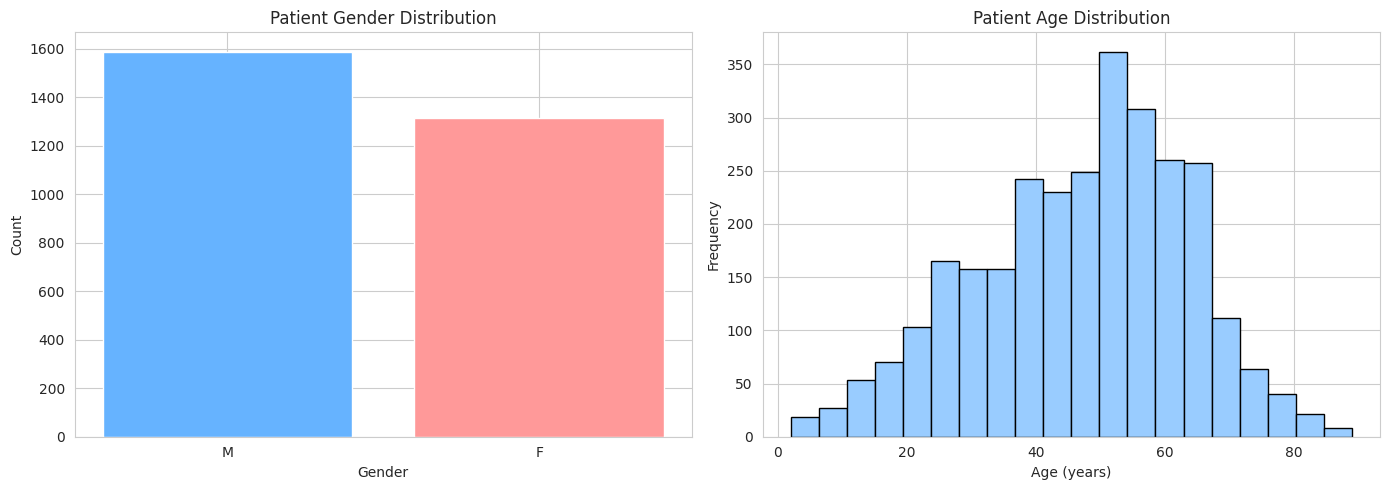

Mean age: 47.16 | Median: 49.00 | Range: 2–89


In [4]:
# Age extraction
df['Age'] = df['Patient Age'].str.extract(r'(\d+)').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution
gender_counts = df['Patient Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#66b3ff','#ff9999'])
axes[0].set_title('Patient Gender Distribution'); axes[0].set_xlabel('Gender'); axes[0].set_ylabel('Count')

# Age distribution
axes[1].hist(df['Age'], bins=20, color='#99ccff', edgecolor='black')
axes[1].set_title('Patient Age Distribution'); axes[1].set_xlabel('Age (years)'); axes[1].set_ylabel('Frequency')

plt.tight_layout(); plt.show()
print(f'Mean age: {df["Age"].mean():.2f} | Median: {df["Age"].median():.2f} | Range: {df["Age"].min()}–{df["Age"].max()}')

All medical findings:
                     Count
Infiltration          464
Effusion              336
Atelectasis           251
Nodule                213
Mass                  187
Pneumothorax          176
Pleural_Thickening    126
Emphysema              82
Consolidation          79
Cardiomegaly           77
Fibrosis               65
Pneumonia              24
Edema                  12
Hernia                 10


<Figure size 1000x600 with 0 Axes>

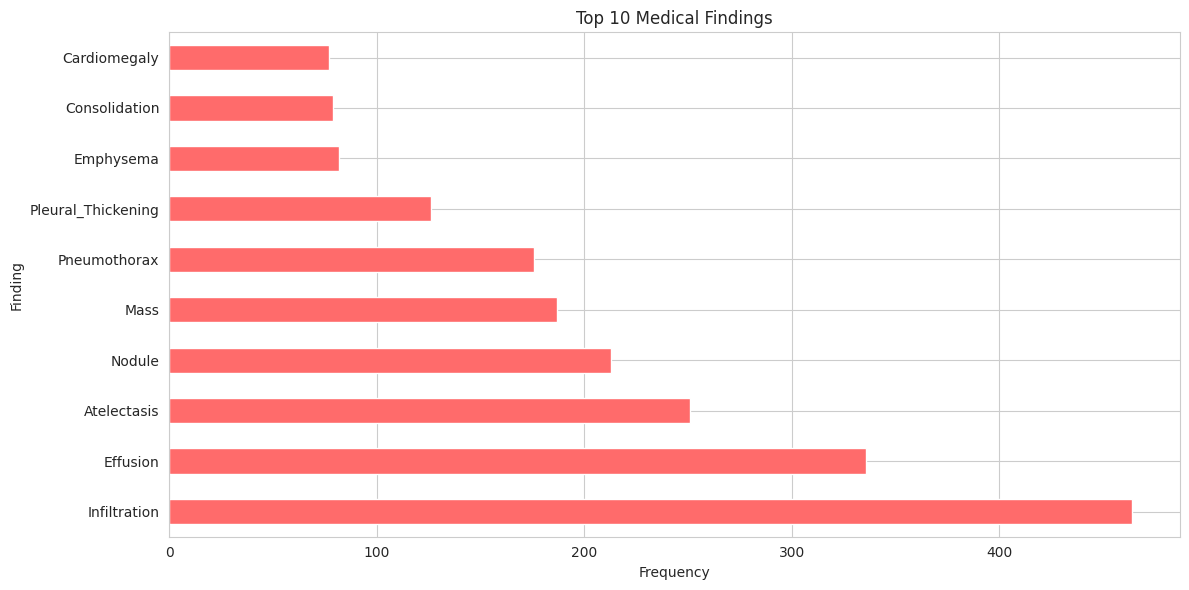


No Finding: 1500 (51.6%)  |  Has Finding: 1406 (48.4%)


In [5]:
# Finding label frequency
all_findings = []
for lbl in df['Finding Labels']:
    if lbl != 'No Finding':
        all_findings.extend(lbl.split('|'))

findings_df = pd.DataFrame.from_dict(Counter(all_findings), orient='index',
                                      columns=['Count']).sort_values('Count', ascending=False)
print('All medical findings:\n', findings_df)

plt.figure(figsize=(10, 6))
findings_df.head(10).plot(kind='barh', color='#ff6b6b', legend=False)
plt.title('Top 10 Medical Findings'); plt.xlabel('Frequency'); plt.ylabel('Finding')
plt.tight_layout(); plt.show()

no_f = (df['Finding Labels'] == 'No Finding').sum()
has_f = len(df) - no_f
print(f'\nNo Finding: {no_f} ({no_f/len(df)*100:.1f}%)  |  Has Finding: {has_f} ({has_f/len(df)*100:.1f}%)')

## 4. Create Binary Classification Labels
Convert multi-label finding strings into binary labels: **0 = "No Finding"** (normal) vs **1 = "With Finding"** (any abnormality present)

In [6]:
df['Binary_Label'] = df['Finding Labels'].apply(lambda x: 0 if x == 'No Finding' else 1)

print('Binary Label Distribution:')
print(df['Binary_Label'].value_counts())
print(f'\nNo Finding (0): {(df["Binary_Label"]==0).sum()}')
print(f'With Finding (1): {(df["Binary_Label"]==1).sum()}')

Binary Label Distribution:
Binary_Label
0    1500
1    1406
Name: count, dtype: int64

No Finding (0): 1500
With Finding (1): 1406


## 5. Stratified Data Split — 70% Train / 10% Validation / 20% Test
Divide dataset while maintaining class balance across splits to ensure representative training, validation, and held-out test sets

In [7]:
image_indices = df['Image Index'].values
labels        = df['Binary_Label'].values

# Step 1: hold out 20% test
train_val_idx, test_idx, train_val_lbl, test_lbl = train_test_split(
    image_indices, labels, test_size=0.20, random_state=42, stratify=labels)

# Step 2: split remaining 80% into 70% train / 10% val
train_idx, val_idx, train_lbl, val_lbl = train_test_split(
    train_val_idx, train_val_lbl, test_size=10/80, random_state=42, stratify=train_val_lbl)

for name, idx, lbl in [('Train', train_idx, train_lbl), ('Val', val_idx, val_lbl), ('Test', test_idx, test_lbl)]:
    print(f'{name:5s}: {len(idx):4d} samples ({len(idx)/len(labels)*100:.1f}%)  '
          f'| No Finding: {(lbl==0).sum()}  With Finding: {(lbl==1).sum()}')

Train: 2033 samples (70.0%)  | No Finding: 1050  With Finding: 983
Val  :  291 samples (10.0%)  | No Finding: 150  With Finding: 141
Test :  582 samples (20.0%)  | No Finding: 300  With Finding: 282


## 6. Custom PyTorch Dataset with Image Preprocessing & Augmentation
- **Base transforms:** Resize to 224×224, normalize (mean=0.5, std=0.5), repeat grayscale → 3 channels for ViT input
- **Train augmentation:** RandomCrop, horizontal flip, rotation (±15°), color jitter, RandomErasing for regularization
- **Val/Test:** No augmentation, deterministic preprocessing

In [8]:
# ─── 6. Custom Dataset with Stronger Preprocessing ───────────────────────────
class ChestXrayDataset(Dataset):
    """
    Loads grayscale X-ray images, resizes to 224×224, repeats to 3 channels.
    IMPROVED: Stronger augmentation + RandomErasing for regularisation.
    """
    def __init__(self, image_indices, labels, images_dir, img_size=224, augment=False):
        self.image_indices = image_indices
        self.labels        = labels
        self.images_dir    = images_dir
        self.img_size      = img_size

        base_tfm = [
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ]
        aug_tfm = [
            transforms.Resize((img_size + 20, img_size + 20)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
        ]
        self.transform = transforms.Compose(aug_tfm if augment else base_tfm)

    def __len__(self):
        return len(self.image_indices)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.image_indices[idx])
        try:
            img    = Image.open(img_path).convert('L')
            tensor = self.transform(img).repeat(3, 1, 1)
        except Exception:
            tensor = torch.zeros(3, self.img_size, self.img_size)
        return tensor, torch.tensor(self.labels[idx], dtype=torch.long)

BATCH_SIZE  = 32
NUM_WORKERS = 2

train_ds = ChestXrayDataset(train_idx, train_lbl, images_dir, augment=True)
val_ds   = ChestXrayDataset(val_idx,   val_lbl,   images_dir)
test_ds  = ChestXrayDataset(test_idx,  test_lbl,  images_dir)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

xb, yb = next(iter(train_loader))
print(f'Batch input shape : {xb.shape}')   # (32, 3, 224, 224)
print(f'Batch labels shape: {yb.shape}')   # (32,)

Batch input shape : torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


## 7. Vision Transformer (ViT-L/16) Architecture & Head Replacement
- **Backbone:** Pretrained ViT-L/16 from torchvision (1024-dim embeddings, 24 transformer blocks)
- **Custom head:** Linear(1024→512) + GELU + Dropout(0.3) + Linear(512→2 classes)
- **Phase 1:** Freeze backbone, train head only (fast convergence on new task)
- **Phase 2:** Unfreeze full network for careful fine-tuning (preserve pretrained features)

In [9]:
# ─── 7. Vision Transformer — Pretrained ViT-L/16 + Custom Head ───────────────
import torchvision.models as tvm

# Load pretrained ViT-L/16
backbone = tvm.vit_l_16(weights=tvm.ViT_L_16_Weights.IMAGENET1K_V1)

# Replace classification head (ViT-L hidden dim = 1024)
backbone.heads = nn.Sequential(
    nn.Linear(1024, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = backbone.to(device)

# Freeze everything except head for Phase 1
def set_trainable(model, full=False):
    for name, param in model.named_parameters():
        param.requires_grad = True if full else ('heads' in name)

set_trainable(model, full=False)

print(f'Total parameters    : {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}  (head only — phase 1)')

with torch.no_grad():
    logits = model(torch.zeros(2, 3, 224, 224).to(device))
print(f'Output logits shape : {logits.shape}')   # (2, 2)



   



Total parameters    : 303,827,458
Trainable parameters: 525,826  (head only — phase 1)
Output logits shape : torch.Size([2, 2])


## 8. Training Configuration — Two-Phase Strategy
| Phase | Epochs | LR | Trainable | Purpose |
|-------|--------|-----|-----------|---------|
| **1** | 1–5 | 1e-3 | Head only | Fast adaptation to new task |
| **2** | 6–30 | 1e-5 | Full network | Careful fine-tuning of backbone |

**Loss:** CrossEntropyLoss with class-weighted balancing + label smoothing (0.1) to handle class imbalance
**Optimizer:** AdamW with weight decay (1e-2) | **Scheduler:** CosineAnnealingLR
**Regularization:** Gradient clipping (max_norm=1.0), mixed precision (AMP), early stopping (patience=7)

In [10]:
# ─── 8. Training Setup ───────────────────────────────────────────────────────
# Two-phase training:
#   Phase 1 (epochs 1–5)  : head only, lr=1e-3  — fast convergence
#   Phase 2 (epochs 6–30) : full network, lr=1e-5 — careful fine-tuning

PHASE1_EPOCHS = 5
TOTAL_EPOCHS  = 30
WEIGHT_DECAY  = 1e-2

class_counts  = np.bincount(train_lbl)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum() * 2
criterion     = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Phase 1 optimizer — head only
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-7)

print(f'Phase 1 (epochs 1–{PHASE1_EPOCHS})  : head only,    lr=1e-3')
print(f'Phase 2 (epochs {PHASE1_EPOCHS+1}–{TOTAL_EPOCHS}) : full network, lr=1e-5')
print(f'Loss: CrossEntropyLoss (weighted + label_smoothing=0.1)')

Phase 1 (epochs 1–5)  : head only,    lr=1e-3
Phase 2 (epochs 6–30) : full network, lr=1e-5
Loss: CrossEntropyLoss (weighted + label_smoothing=0.1)


## 9. Training Loop with Phase Transition
- Mixed-precision training (autocast + GradScaler) for GPU memory efficiency
- Phase transition at epoch 6: Unfreeze backbone, lower learning rate, reset early stopping patience
- Per-epoch metrics: training/validation loss & accuracy with learning rate scheduling
- Best model saved based on highest validation accuracy (early stopping)

In [11]:
# ─── 9. Train & Validate (AMP-enabled) ─────────────────────────────────────
scaler = torch.cuda.amp.GradScaler()

def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            if train: optimizer.zero_grad()

            # autocast for mixed precision
            with torch.cuda.amp.autocast():
                out  = model(imgs)
                loss = criterion(out, lbls)

            if train:
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
            preds    = out.argmax(1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return total_loss / len(loader), 100.0 * correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, best_state, patience_counter = 0.0, None, 0
PATIENCE = 7   # or 12 if you want longer tolerance

print('Starting training...')
print('=' * 70)

for epoch in range(1, TOTAL_EPOCHS + 1):

    # ── Phase transition ──────────────────────────────────────────────────────
    if epoch == PHASE1_EPOCHS + 1:
        print(f'\n--- Phase 2: unfreezing full network, lr → 1e-5 ---\n')
        set_trainable(model, full=True)
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=TOTAL_EPOCHS - PHASE1_EPOCHS, eta_min=1e-7)
        patience_counter = 0   # reset patience for fine-tuning phase

    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, train=False)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

    marker = ''
    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker           = ' ← best'
    else:
        patience_counter += 1

    phase = '1' if epoch <= PHASE1_EPOCHS else '2'
    print(f'[P{phase}] Epoch {epoch:02d}/{TOTAL_EPOCHS}  '
          f'Train loss: {tr_loss:.4f} acc: {tr_acc:.2f}%  '
          f'| Val loss: {vl_loss:.4f} acc: {vl_acc:.2f}%  '
          f'lr: {current_lr:.2e}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

print('=' * 70)
print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
model.load_state_dict(best_state)
torch.save(best_state, 'best_vit_chest_xray.pth')
print('Best model saved → best_vit_chest_xray.pth')

Starting training...
[P1] Epoch 01/30  Train loss: 0.6721 acc: 60.75%  | Val loss: 0.7756 acc: 60.48%  lr: 9.97e-04 ← best
[P1] Epoch 02/30  Train loss: 0.6571 acc: 62.27%  | Val loss: 0.6559 acc: 67.35%  lr: 9.89e-04 ← best
[P1] Epoch 03/30  Train loss: 0.6438 acc: 64.78%  | Val loss: 0.6417 acc: 68.38%  lr: 9.76e-04 ← best
[P1] Epoch 04/30  Train loss: 0.6521 acc: 64.14%  | Val loss: 0.6226 acc: 65.29%  lr: 9.57e-04
[P1] Epoch 05/30  Train loss: 0.6610 acc: 62.22%  | Val loss: 0.6508 acc: 67.70%  lr: 9.33e-04

--- Phase 2: unfreezing full network, lr → 1e-5 ---

[P2] Epoch 06/30  Train loss: 0.6352 acc: 66.26%  | Val loss: 0.6287 acc: 70.10%  lr: 9.96e-06 ← best
[P2] Epoch 07/30  Train loss: 0.6282 acc: 65.72%  | Val loss: 0.6236 acc: 69.07%  lr: 9.84e-06
[P2] Epoch 08/30  Train loss: 0.6198 acc: 67.58%  | Val loss: 0.5996 acc: 70.10%  lr: 9.65e-06
[P2] Epoch 09/30  Train loss: 0.6147 acc: 68.47%  | Val loss: 0.6087 acc: 70.45%  lr: 9.39e-06 ← best
[P2] Epoch 10/30  Train loss: 0.608

## 10. Training & Validation Curves
Visualize loss and accuracy trajectories across training epochs. Identifies overfitting, convergence issues, and effectiveness of phase transitions

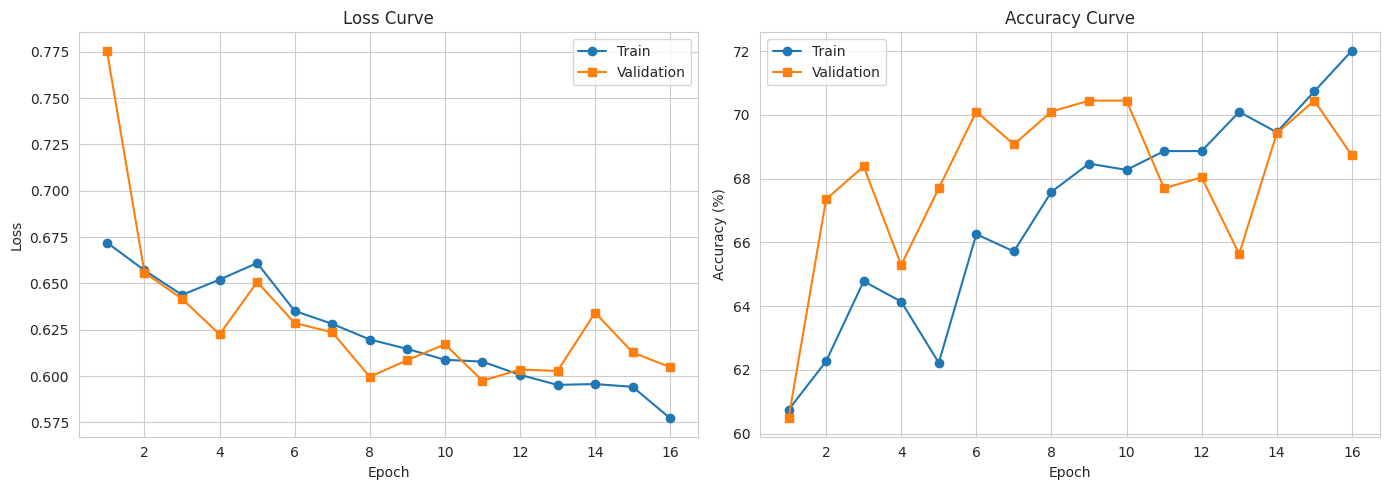

In [14]:
# ─── 10. Training History Plots ──────────────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)  # actual epochs run

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   marker='s', label='Validation')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, history['train_acc'], marker='o', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   marker='s', label='Validation')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

## 11. Comprehensive Test Set Evaluation — All Classification Metrics
**Overall metrics:** Accuracy, Precision, Recall, F1-Score (weighted), ROC-AUC
**Per-class metrics:** Precision, Recall, F1 for "No Finding" vs "With Finding"
**Diagnostic metrics:** True/False Positives/Negatives, Sensitivity, Specificity, FPR, FNR
**Visualizations:** Confusion matrix heatmap + ROC curve

In [18]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out   = model(imgs)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Overall Metrics ─────────────────────────────────────────────────
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(   all_labels, all_preds, average='weighted', zero_division=0)
f1        = f1_score(       all_labels, all_preds, average='weighted', zero_division=0)
roc_auc   = roc_auc_score(all_labels, all_probs[:, 1])

print('=' * 60)
print('TEST SET — OVERALL PERFORMANCE')
print('=' * 60)
print(f'Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'Precision : {precision:.4f}  (weighted)')
print(f'Recall    : {recall:.4f}  (weighted)')
print(f'F1-Score  : {f1:.4f}  (weighted)')
print(f'ROC-AUC   : {roc_auc:.4f}')
print('=' * 60)

TEST SET — OVERALL PERFORMANCE
Accuracy  : 0.6838  (68.38%)
Precision : 0.7012  (weighted)
Recall    : 0.6838  (weighted)
F1-Score  : 0.6741  (weighted)
ROC-AUC   : 0.7603


In [19]:
# ── Per-Class Metrics ────────────────────────────────────────────────
prec_cls = precision_score(all_labels, all_preds, average=None, zero_division=0)
rec_cls  = recall_score(   all_labels, all_preds, average=None, zero_division=0)
f1_cls   = f1_score(       all_labels, all_preds, average=None, zero_division=0)

print('\nPER-CLASS PERFORMANCE')
print('-' * 50)
for i, cls in enumerate(['No Finding', 'With Finding']):
    print(f'{cls}:')
    print(f'  Precision : {prec_cls[i]:.4f}')
    print(f'  Recall    : {rec_cls[i]:.4f}')
    print(f'  F1-Score  : {f1_cls[i]:.4f}')

# ── Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print('\nDIAGNOSTIC METRICS')
print('-' * 50)
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')
print(f'Sensitivity (TPR)   : {sensitivity:.4f}')
print(f'Specificity (TNR)   : {specificity:.4f}')
print(f'False Positive Rate : {1 - specificity:.4f}')
print(f'False Negative Rate : {1 - sensitivity:.4f}')

print('\nDETAILED CLASSIFICATION REPORT')
print(classification_report(all_labels, all_preds,
                             target_names=['No Finding', 'With Finding']))


PER-CLASS PERFORMANCE
--------------------------------------------------
No Finding:
  Precision : 0.6480
  Recall    : 0.8467
  F1-Score  : 0.7341
With Finding:
  Precision : 0.7579
  Recall    : 0.5106
  F1-Score  : 0.6102

DIAGNOSTIC METRICS
--------------------------------------------------
True Negatives  (TN): 254
False Positives (FP): 46
False Negatives (FN): 138
True Positives  (TP): 144
Sensitivity (TPR)   : 0.5106
Specificity (TNR)   : 0.8467
False Positive Rate : 0.1533
False Negative Rate : 0.4894

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Finding       0.65      0.85      0.73       300
With Finding       0.76      0.51      0.61       282

    accuracy                           0.68       582
   macro avg       0.70      0.68      0.67       582
weighted avg       0.70      0.68      0.67       582



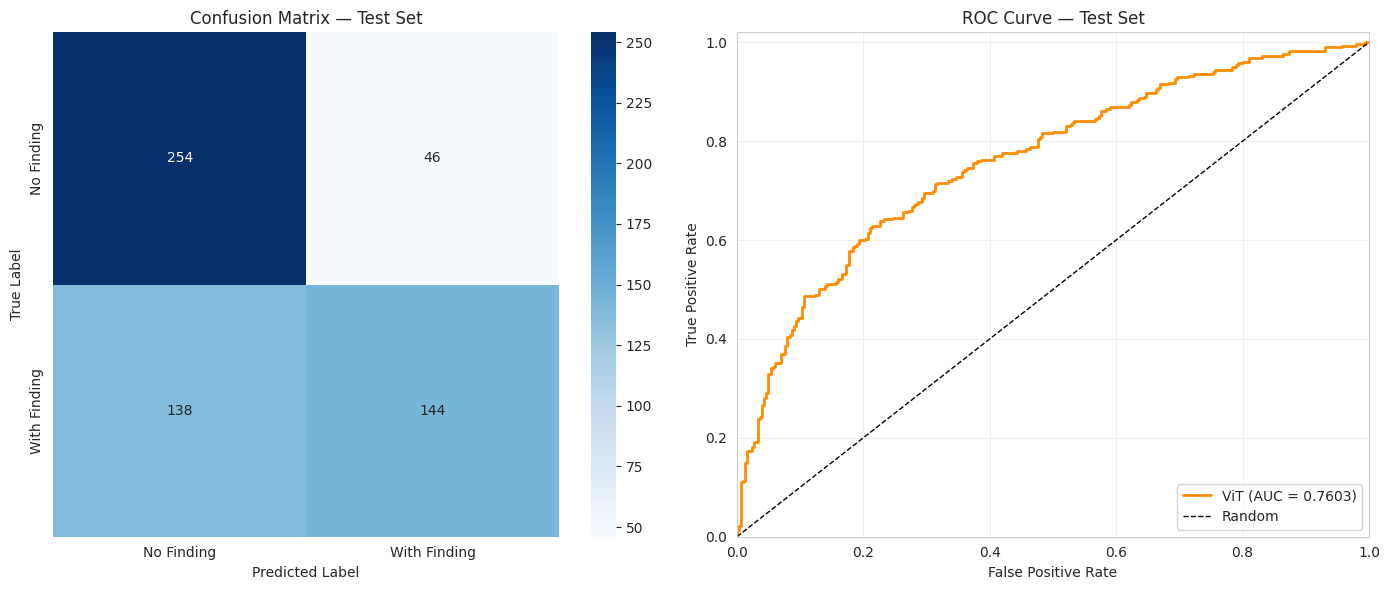

In [20]:
# ── Visualisations: Confusion Matrix + ROC Curve ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Finding', 'With Finding'],
            yticklabels=['No Finding', 'With Finding'])
axes[0].set_title('Confusion Matrix — Test Set')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ViT (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 12. Final Summary Report
Consolidated summary of dataset sizes, model architecture, training configuration, and final test-set performance across all key metrics

In [23]:
print('=' * 80)
print('VISION TRANSFORMER — CHEST X-RAY BINARY CLASSIFICATION — FINAL SUMMARY')
print('=' * 80)

print('\n📂 DATASET')
print(f'  Total Images      : {len(image_indices)}')
print(f'  Training Samples  : {len(train_idx)}  (70%)')
print(f'  Validation Samples: {len(val_idx)}   (10%)')
print(f'  Test Samples      : {len(test_idx)}   (20%)')

print('\n🏗  MODEL ARCHITECTURE')
print(f'  Model             : Vision Transformer (ViT-Base/16 from scratch)')
print(f'  Input Size        : 224 × 224 × 3')
print(f'  Patch Size        : 16 × 16  → 196 patches')
print(f'  Embedding Dim     : 768')
print(f'  Transformer Blocks: 12')
print(f'  Attention Heads   : 12')
print(f'  MLP Ratio         : 4.0  (hidden dim = 3072)')
print(f'  Total Parameters  : {sum(p.numel() for p in model.parameters()):,}')

print('\n⚙  TRAINING')
print(f'  Scheduler         : CosineAnnealingLR')
print(f'  Loss              : CrossEntropyLoss (label_smoothing=0.1)')
print(f'  Best Val Accuracy : {best_val_acc:.2f}%')

print('\n📊 TEST SET PERFORMANCE')
print(f'  Accuracy          : {accuracy*100:.2f}%')
print(f'  Precision (wtd)   : {precision:.4f}')
print(f'  Recall (wtd)      : {recall:.4f}')
print(f'  F1-Score (wtd)    : {f1:.4f}')
print(f'  ROC-AUC           : {roc_auc:.4f}')
print(f'  Sensitivity (TPR) : {sensitivity:.4f}')
print(f'  Specificity (TNR) : {specificity:.4f}')
print('=' * 80)

VISION TRANSFORMER — CHEST X-RAY BINARY CLASSIFICATION — FINAL SUMMARY

📂 DATASET
  Total Images      : 2906
  Training Samples  : 2033  (70%)
  Validation Samples: 291   (10%)
  Test Samples      : 582   (20%)

🏗  MODEL ARCHITECTURE
  Model             : Vision Transformer (ViT-Base/16 from scratch)
  Input Size        : 224 × 224 × 3
  Patch Size        : 16 × 16  → 196 patches
  Embedding Dim     : 768
  Transformer Blocks: 12
  Attention Heads   : 12
  MLP Ratio         : 4.0  (hidden dim = 3072)
  Total Parameters  : 303,827,458

⚙  TRAINING
  Scheduler         : CosineAnnealingLR
  Loss              : CrossEntropyLoss (label_smoothing=0.1)
  Best Val Accuracy : 70.45%

📊 TEST SET PERFORMANCE
  Accuracy          : 68.38%
  Precision (wtd)   : 0.7012
  Recall (wtd)      : 0.6838
  F1-Score (wtd)    : 0.6741
  ROC-AUC           : 0.7603
  Sensitivity (TPR) : 0.5106
  Specificity (TNR) : 0.8467
